In [86]:
import pandas as pd
import numpy as np
import seaborn as sns

In [17]:
file_path = "data/Otodom_Flat_Listings.csv"
otodom_flats = pd.read_csv(file_path)

## Zadanie 1

In [47]:
print(f"Wartosci większe od 0 dla cechy Price {np.sum(otodom_flats.Price.apply(lambda x:  x > 0))/ df.shape[0]*100:.2f} %")

Wartosci większe od 0 dla cechy Price 94.91 %


In [48]:
for feature in otodom_flats.columns:
    print(f"Kompletność dla {feature} wynosi : {(1- (np.sum(otodom_flats[feature].isna()) / otodom_flats.shape[0])) *100:.2f} %")

Kompletność dla Title wynosi : 100.00 %
Kompletność dla Price wynosi : 94.91 %
Kompletność dla Location wynosi : 99.96 %
Kompletność dla Surface wynosi : 100.00 %
Kompletność dla Number_of_Rooms wynosi : 100.00 %
Kompletność dla Floor wynosi : 97.72 %
Kompletność dla Finishing_Condition wynosi : 79.41 %
Kompletność dla Heating wynosi : 73.39 %
Kompletność dla Parking_Space wynosi : 52.65 %
Kompletność dla Balcony_Garden_Terrace wynosi : 74.88 %
Kompletność dla Link wynosi : 100.00 %
Kompletność dla Voivodeship wynosi : 99.96 %
Kompletność dla City wynosi : 99.96 %


In [49]:
otodom_flats_map = otodom_flats.isna()
completness = 1 - (np.sum(otodom_flats_map.values) / (otodom_flats_map.shape[0] * otodom_flats_map.shape[1]))
print(f"Dane są kompletne w {completness *100:.2f} %")

Dane są kompletne w 90.22 %


## Zadanie 2

In [78]:
df_cleaned = otodom_flats.dropna(subset=["Price"])
df_cleaned['Price'] = pd.to_numeric(df_cleaned['Price'], errors='coerce')
df_cleaned['Price'].dtype

dtype('float64')

<Axes: ylabel='Frequency'>

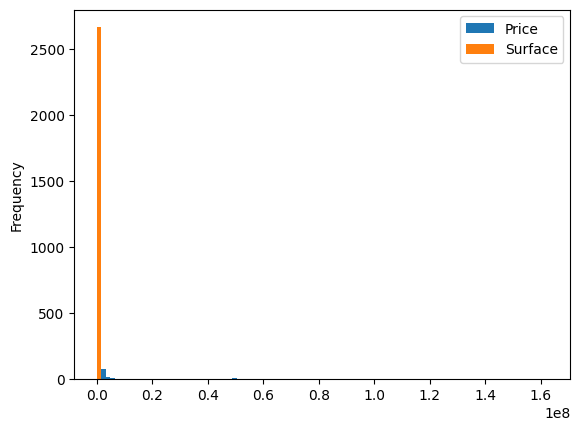

In [83]:
df_cleaned.plot.hist(bins = 100)


In [ ]:
## zrobic dla mniejszych probek

In [85]:
df_cleaned['Price'].describe

<bound method NDFrame.describe of 0        415000.0
1       2499000.0
2        649000.0
3       2108000.0
4        450180.0
          ...    
2802     525000.0
2803     829000.0
2804     830000.0
2805     699000.0
2806    1450000.0
Name: Price, Length: 2664, dtype: float64>

## Zadanie 3

<Axes: ylabel='Price'>

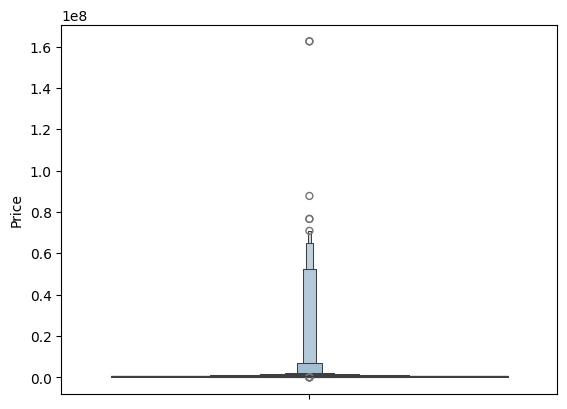

In [88]:
sns.boxenplot(df_cleaned['Price'])

<Axes: >

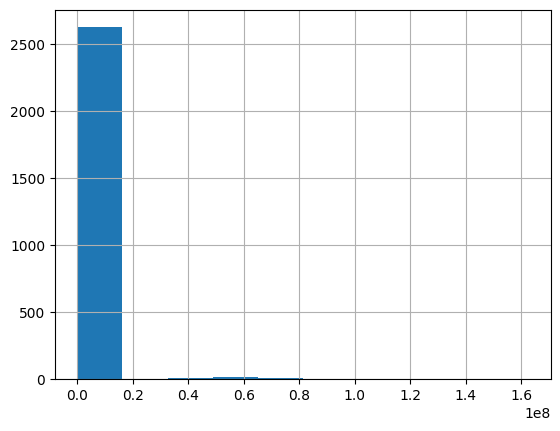

In [91]:
Q1 = df_cleaned['Price'].quantile(0.25)
Q3 = df_cleaned['Price'].quantile(0.75)
IQR = Q3-Q1

dolna_granica = Q1 - 1.5 * IQR
gorna_granica = Q3 + 1.5 * IQR
outlier_data = df_cleaned[(df_cleaned['Price'] < dolna_granica) | (df_cleaned['Price'] > gorna_granica)]
outlier_data['Price'].hist(bins = 10)